In [1]:
import keras
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import sys
sys.path.append("../")

In [2]:
DATA_DIR = "../mu3e_trigger_data"
SIGNAL_DATA_FILE = f"{DATA_DIR}/run42_sig_positions.npy"
BACKGROUND_DATA_FILE = f"{DATA_DIR}/run42_bg_positions.npy"

max_barrel_radius = 86.3
max_endcap_distance = 372.6

In [3]:
signal_data = np.load(SIGNAL_DATA_FILE)
background_data = np.load(BACKGROUND_DATA_FILE)


In [4]:
bg_mask = background_data[:, :, 0] != -1
signal_mask = signal_data[:, :, 0] != -1
bg_seq_length = bg_mask.sum(axis=1)
signal_seq_length = signal_mask.sum(axis=1)

background_data = background_data[bg_seq_length > 0]
signal_data = signal_data[signal_seq_length > 0]

In [5]:
sequence_length = signal_data.shape[1]
input_feature_dim = signal_data.shape[2]
feature_dim = 16

In [6]:
from src.utils import cartesian_to_cylindrical
signal_data_cylindrical = cartesian_to_cylindrical(signal_data)
background_data_cylindrical = cartesian_to_cylindrical(background_data)

In [7]:
from src.model.components import MLP, GenerateMask
lstm_encoder_input = keras.Input(
    shape=(sequence_length, 3), name="lstm_encoder_input"
)
lstm_mask = GenerateMask(padding_value=-1)(lstm_encoder_input)
lstm_embedding = MLP(
    feature_dim, num_layers=3, hidden_activation="relu", activation="linear", name="lstm_embedding_mlp"
)(lstm_encoder_input)
lstm_layer_1 = keras.layers.Bidirectional(keras.layers.LSTM(
    feature_dim, return_sequences=True, name="lstm_layer_1"
))(lstm_embedding, mask=lstm_mask)
lstm_layer_2 = keras.layers.Bidirectional(keras.layers.LSTM(
    feature_dim, return_sequences=True, name="lstm_layer_2"
))(lstm_layer_1, mask=lstm_mask)
lstm_output = keras.layers.LSTM(feature_dim, return_sequences=True, name="lstm_output")(lstm_layer_2, mask=lstm_mask)

output = keras.layers.Dense(
    feature_dim, activation="linear", name="lstm_output_dense")(lstm_output)

pooled_output = keras.layers.GlobalAveragePooling1D(name="lstm_pooled_output")(output, mask=lstm_mask)

output = MLP(
    feature_dim, num_layers=3, hidden_activation="relu", activation="linear", name="lstm_output_mlp"
)(pooled_output)

lstm_encoder = keras.Model(
    inputs=lstm_encoder_input,
    outputs=output,
    name="lstm_encoder",
)
lstm_encoder.summary()


Model: "lstm_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ lstm_encoder_input  │ (None, 256, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_embedding_mlp  │ (None, 256, 16)   │        468 │ lstm_encoder_inp… │
│ (MLP)               │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generate_mask       │ (None, 256, 1)    │          0 │ lstm_encoder_inp… │
│ (GenerateMask)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 256, 32)   │      4,224 │ lstm_embedding_m… │
│ (Bidirectional)     │                   │            │ generate_mask[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 256, 32)   │      6,272 │ bidirectional[0]… │
│ (Bidirectional)     │                   │            │ generate_mask[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_output (LSTM)  │ (None, 256, 16)   │      3,136 │ bidirectional_1[… │
│                     │                   │            │ generate_mask[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_output_dense   │ (None, 256, 16)   │        272 │ lstm_output[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_pooled_output  │ (None, 16)        │          0 │ lstm_output_dens… │
│ (GlobalAveragePool… │                   │            │ generate_mask[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_output_mlp     │ (None, 16)        │      1,632 │ lstm_pooled_outp… │
│ (MLP)               │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,954 (58.41 KB)

 Trainable params: 14,954 (58.41 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
from src.model import AutoEncoder
autoencoder = AutoEncoder(
    input_size = feature_dim,
    latent_dim =  feature_dim // 2,
    num_layers = 4
)

In [ ]:
from src.training import MultiObjectiveTrainer
from src.training import VarianceCovarianceLoss, EmbeddingSpaceSpreading

trainer = MultiObjectiveTrainer(
    encoder=lstm_encoder,
    autoencoder=autoencoder,
    lambda_var=.5,
    variance_loss = EmbeddingSpaceSpreading(var_penalty = 10, cov_penatly = 1)
)
encoder_optimizer = keras.optimizers.Adam(learning_rate=0.001)
ae_optimizer = keras.optimizers.Adam(learning_rate=0.01)

In [10]:
from sklearn.model_selection import train_test_split

bg_train, bg_test = train_test_split(background_data_cylindrical[:100000], test_size=0.2, random_state=42)

bg_train = tf.data.Dataset.from_tensor_slices(bg_train).batch(512, drop_remainder=True)


In [11]:
for var_epoch in range(5):
    print(f"  Variance Epoch {var_epoch + 1}")
    losses = trainer.train_encoder_variance_step(bg_train, encoder_optimizer)
    print(f"    Losses: {losses}")

for epoch in range(5):
    print(f"Epoch {epoch + 1}")
    print(f"  Autoencoder Epochs")
    losses = trainer.train_autoencoder_step(bg_train, ae_optimizer, num_steps=10)
    for loss in losses:
        print(f"    Loss: {loss}")

    for recon_epoch in range(5):
        print(f"  Reconstruction Epoch {recon_epoch + 1}")
        losses = trainer.train_encoder_step(bg_train, encoder_optimizer)
        print(f"    Losses: {losses}")


  Variance Epoch 1
    Losses: 0.4401155114173889
  Variance Epoch 2
    Losses: 0.26036083698272705
  Variance Epoch 3
    Losses: -0.24417032301425934
  Variance Epoch 4
    Losses: -0.4072355031967163
  Variance Epoch 5
    Losses: -0.472774863243103
Epoch 1
  Autoencoder Epochs
    Loss: 0.6763916015625
    Loss: 0.41874152421951294
    Loss: 0.31275394558906555
    Loss: 0.25609585642814636
    Loss: 0.22284717857837677
    Loss: 0.1955215483903885
    Loss: 0.1739112287759781
    Loss: 0.15687678754329681
    Loss: 0.14871321618556976
    Loss: 0.14429661631584167
  Reconstruction Epoch 1
    Losses: (<tf.Tensor: shape=(), dtype=float32, numpy=0.06088511645793915>, <tf.Tensor: shape=(), dtype=float32, numpy=-0.43330565094947815>)
  Reconstruction Epoch 2
    Losses: (<tf.Tensor: shape=(), dtype=float32, numpy=0.04176262766122818>, <tf.Tensor: shape=(), dtype=float32, numpy=-0.4279782772064209>)
  Reconstruction Epoch 3
    Losses: (<tf.Tensor: shape=(), dtype=float32, numpy=0.036

In [12]:
trainer.train_autoencoder_step(bg_train, ae_optimizer, num_steps=10)

[<tf.Tensor: shape=(), dtype=float32, numpy=0.15713389217853546>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.15409080684185028>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.1535273641347885>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.1532386988401413>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.15282125771045685>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.15256372094154358>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.152411550283432>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.15246917307376862>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.15193042159080505>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.1521615982055664>]

In [ ]:
for recon_epoch in range(5):
    print(f"Reconstruction Epoch {recon_epoch + 1}")
    losses = trainer.train_encoder_step(bg_train, encoder_optimizer)
    print(f"  Losses: {losses}")
    losses = trainer.train_autoencoder_step(bg_train, ae_optimizer, num_steps=4)
    print(f"  Autoencoder Losses: {losses}")



In [17]:
bg_test_embeddings = lstm_encoder.predict(bg_test)
signal_embeddings = lstm_encoder.predict(signal_data_cylindrical[:20000])
bg_train_embeddings = lstm_encoder.predict(bg_train)

623/623 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step
155/155 ━━━━━━━━━━━━━━━━━━━━ 51s 331ms/step


In [18]:
bg_test_diff = bg_test_embeddings - autoencoder.predict(bg_test_embeddings)
signal_diff = signal_embeddings - autoencoder.predict(signal_embeddings)
bg_train_diff = bg_train_embeddings - autoencoder.predict(bg_train_embeddings)

623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 578us/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 555us/step
2480/2480 ━━━━━━━━━━━━━━━━━━━━ 1s 537us/step


In [19]:
(np.abs(np.cov(bg_test_embeddings, rowvar=False)-np.diag(np.cov(bg_test_embeddings, rowvar=False).diagonal()))).max()

np.float64(0.1306283751909831)

In [27]:
import src.evaluation.PlotUtils as eval
from importlib import reload
reload(eval)

<module 'src.evaluation.PlotUtils' from '/Users/simi/mu3e_trigger/notebooks/../src/evaluation/PlotUtils.py'>

(<Figure size 1400x1000 with 16 Axes>,
 array([[<Axes: xlabel='$\\sigma$ 1', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 2', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 3', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 4', ylabel='Density'>],
        [<Axes: xlabel='$\\sigma$ 5', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 6', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 7', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 8', ylabel='Density'>],
        [<Axes: xlabel='$\\sigma$ 9', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 10', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 11', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 12', ylabel='Density'>],
        [<Axes: xlabel='$\\sigma$ 13', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 14', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 15', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 16', ylabel='Density'>]], dtype=object))

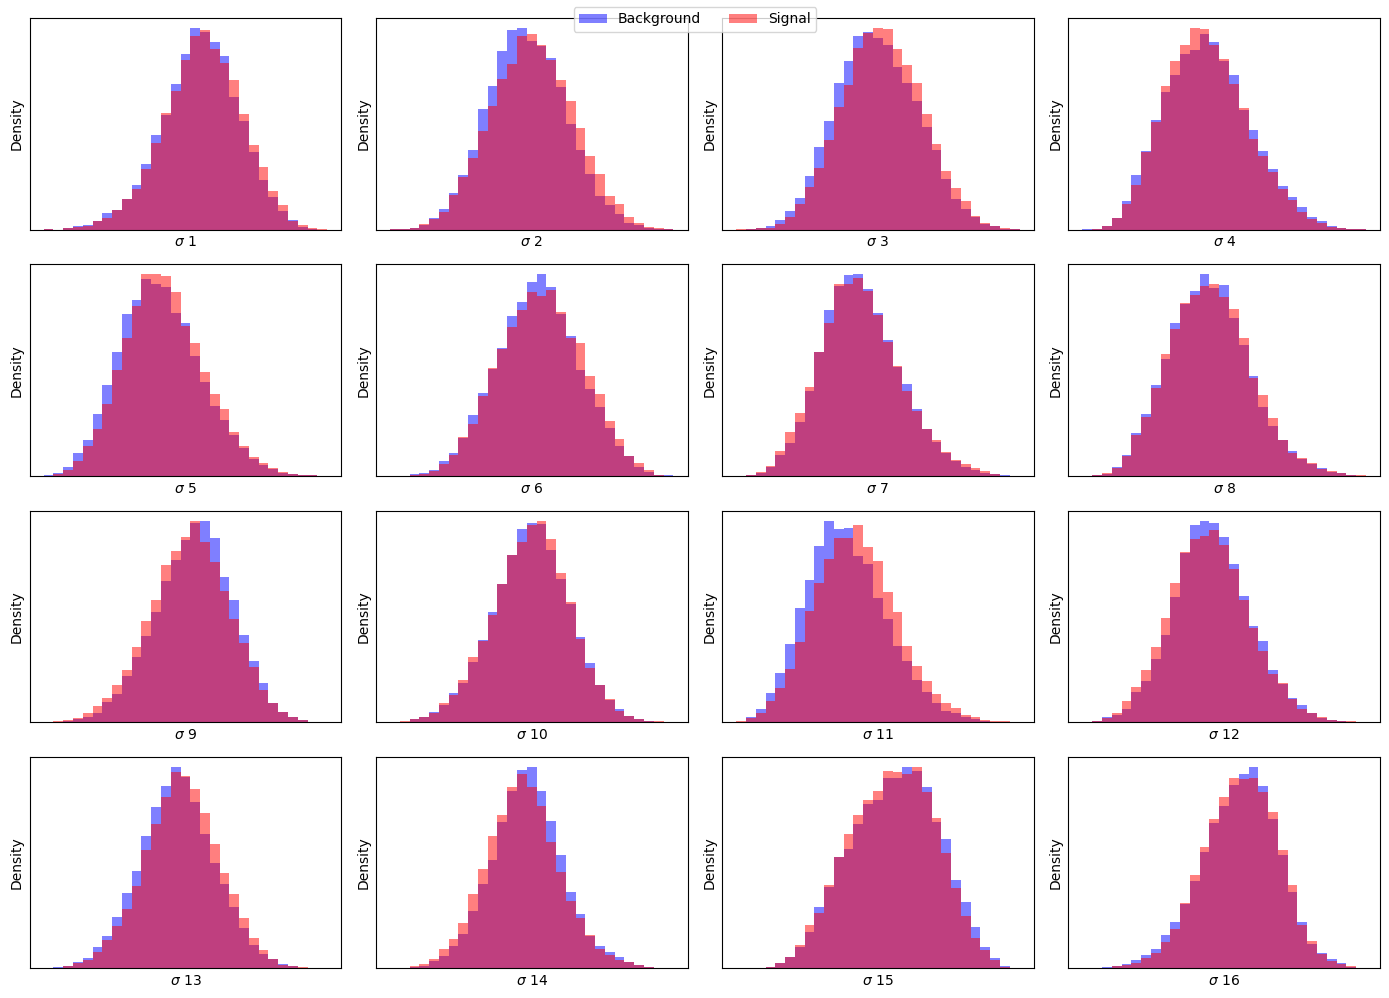

In [28]:
eval.plot_latent_variable_distributions(
    bg_test_embeddings, signal_embeddings, feature_dim=32, save_path="ad_scores_train_test.png"
)

(<Figure size 1400x1000 with 16 Axes>,
 array([[<Axes: xlabel='$\\sigma$ 1', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 2', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 3', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 4', ylabel='Density'>],
        [<Axes: xlabel='$\\sigma$ 5', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 6', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 7', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 8', ylabel='Density'>],
        [<Axes: xlabel='$\\sigma$ 9', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 10', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 11', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 12', ylabel='Density'>],
        [<Axes: xlabel='$\\sigma$ 13', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 14', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 15', ylabel='Density'>,
         <Axes: xlabel='$\\sigma$ 16', ylabel='Density'>]], dtype=object))

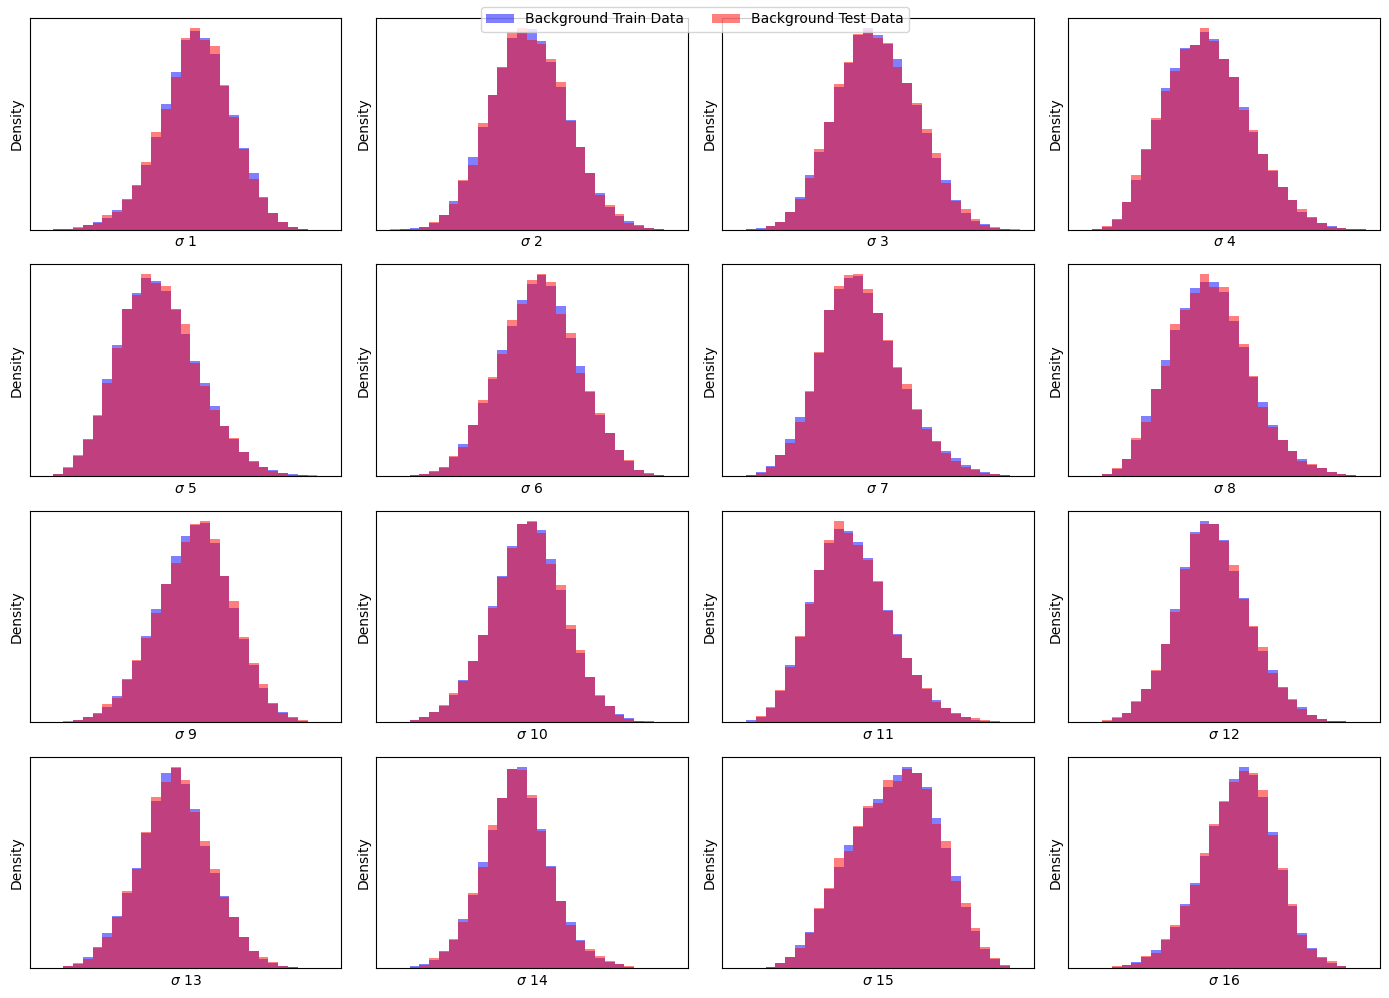

In [29]:
eval.plot_latent_variable_distributions(
    bg_train_embeddings, bg_test_embeddings, feature_dim=32, save_path="ad_scores_train_train.png", signal_label="Background Test Data", background_label="Background Train Data"
)

AttributeError: 'Axes' object has no attribute 'flatten'

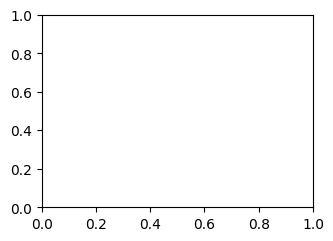

In [30]:
eval.plot_latent_variable_distributions(
    np.max(np.abs(bg_test_diff),axis = 1), np.max(np.abs(signal_diff),axis = 1), feature_dim=32
)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
bg_ad_score = np.linalg.norm(bg_test_diff, axis=1)
signal_ad_score = np.linalg.norm(signal_diff, axis=1)
bins = np.linspace(
    min(np.min(bg_ad_score), np.min(signal_ad_score)),
    max(np.max(bg_ad_score), np.max(signal_ad_score)),
    30,
)
ax.hist(
    bg_ad_score,
    bins=bins,
    alpha=0.5,
    label="Background Data",
    color="blue",
    density=True,
)
ax.hist(
    signal_ad_score,
    bins=bins,
    alpha=0.5,
    label="Signal Data",
    color="red",
    density=True,
)

ax.set_xlabel(f"MSE")
ax.set_ylabel("Density")
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)
fig.savefig("ad_scores_train_test.png", dpi=300, bbox_inches="tight")

In [ ]:
mu = np.mean(bg_train_diff, axis=0)
sigma = np.std(bg_train_diff, axis=0)

def shuffle_data(data, feature_axis = -1):
    if feature_axis != -1:
        data = np.moveaxis(data, feature_axis, -1)
    features = data.shape[-1]
    shuffled_data = data.copy()
    for i in range(features):
        shuffled_data[..., i] = np.random.permutation(data[..., i])
    data = np.moveaxis(data, -1, feature_axis)
    return np.moveaxis(shuffled_data, -1, feature_axis)

dummy_data = shuffle_data(bg_train_diff)
dummy_data_diff = dummy_data - autoencoder.predict(dummy_data)

In [ ]:
import src.evaluation.PlotUtils as evaluation
from importlib import reload
reload(evaluation)
evaluation.plot_latent_variable_distributions(
    np.abs(bg_test_diff),
    np.abs(dummy_data_diff),
    signal_label="Test Data",
    background_label="Dummy Data",
)